In [470]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("Environment setup completed successfully!")

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Environment setup completed successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3


In [471]:
# Check missing values

missing = df.isnull().sum()

print("Missing values in each column:")
display(missing[missing > 0])

Missing values in each column:


,0
Unnamed: 20,4999
Unnamed: 21,4994


In [472]:
from google.colab import files

uploaded = files.upload()

Saving Sales_Analysis_Dataset.xlsx to Sales_Analysis_Dataset (34).xlsx


In [473]:
# Save cleaned sales dataset

df.to_csv('cleaned_sales_data.csv', index=False)

print("cleaned_sales_data.csv created successfully!")

cleaned_sales_data.csv created successfully!


In [474]:
from google.colab import files

files.download('cleaned_sales_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [475]:
# Create Profit_Status

df['Profit_Status'] = np.where(
    df['Profit'] >= 0,
    'Profitable',
    'Loss'
)

print("Profit_Status created!")
print(df['Profit_Status'].value_counts())

Profit_Status created!
Profit_Status
Profitable    4459
Loss           541
Name: count, dtype: int64


In [476]:
# Define features and target

X = df.drop(columns=['Profit_Status'])
y = df['Profit_Status']

print("X created successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

X created successfully!
X shape: (5000, 22)
y shape: (5000,)


In [477]:
# Remove unnecessary columns

columns_to_drop = [
    'Order_ID',
    'Customer_Name',
    'Order_Date'
]

X = X.drop(
    columns=[col for col in columns_to_drop if col in X.columns]
)

print("Unnecessary columns removed!")
print("Final X shape:", X.shape)

Unnecessary columns removed!
Final X shape: (5000, 19)


In [478]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nTarget distribution:")
print(y.value_counts())

Features:
['Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']

Target:
Profit_Status

Target distribution:
Profit_Status
Profitable    4459
Loss           541
Name: count, dtype: int64


In [479]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4000
Testing samples: 1000


In [480]:
# Create Profit_Status feature

df['Profit_Status'] = np.where(
    df['Profit'] >= 0,
    'Profitable',
    'Loss'
)

print("Profit_Status created successfully!")
print(df['Profit_Status'].value_counts())

Profit_Status created successfully!
Profit_Status
Profitable    4459
Loss           541
Name: count, dtype: int64


In [481]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21', 'Profit_Status']


In [482]:
# Define features (X) and target (y)

X = df.drop(columns=['Profit_Status'])
y = df['Profit_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (5000, 22)
Target shape: (5000,)

Target distribution:
Profit_Status
Profitable    4459
Loss           541
Name: count, dtype: int64


In [483]:
# Remove columns that should not be used directly

columns_to_drop = [
    'Order_ID',
    'Customer_Name',
    'Order_Date'
]

X = X.drop(
    columns=[col for col in columns_to_drop if col in X.columns]
)

print("Features prepared successfully!")
print("Number of features:", X.shape[1])

Features prepared successfully!
Number of features: 19


In [484]:
numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Year', 'Month_Number', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']

Categorical features:
['Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Payment_Method', 'Month', 'Quarter']


In [485]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

print("ML preprocessing pipeline created successfully!")

ML preprocessing pipeline created successfully!


In [486]:
# Fit preprocessing only on training data

X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted pipeline
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (4000, 91)
Testing data after preprocessing: (1000, 91)


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 20']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 20']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [487]:
# Identify numerical columns

numerical_columns = df_encoded.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print(numerical_columns)

Number of numerical columns: 5114
['Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Year', 'Month_Number', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21', 'Order_ID_ORD00001', 'Order_ID_ORD00002', 'Order_ID_ORD00003', 'Order_ID_ORD00004', 'Order_ID_ORD00005', 'Order_ID_ORD00006', 'Order_ID_ORD00007', 'Order_ID_ORD00008', 'Order_ID_ORD00009', 'Order_ID_ORD00010', 'Order_ID_ORD00011', 'Order_ID_ORD00012', 'Order_ID_ORD00013', 'Order_ID_ORD00014', 'Order_ID_ORD00015', 'Order_ID_ORD00016', 'Order_ID_ORD00017', 'Order_ID_ORD00018', 'Order_ID_ORD00019', 'Order_ID_ORD00020', 'Order_ID_ORD00021', 'Order_ID_ORD00022', 'Order_ID_ORD00023', 'Order_ID_ORD00024', 'Order_ID_ORD00025', 'Order_ID_ORD00026', 'Order_ID_ORD00027', 'Order_ID_ORD00028', 'Order_ID_ORD00029', 'Order_ID_ORD00030', 'Order_ID_ORD00031', 'Order_ID_ORD00032', 'Order_ID_ORD00033', 'Order_ID_ORD00034', 'Order_ID_ORD00035', 'Order_ID_ORD00036', 'Order_ID_ORD00037', 'Order_ID_ORD00038', 'Order_ID_ORD00039', 'Order_ID_ORD00040

In [488]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df_encoded.copy()

df_scaled[numerical_columns] = scaler.fit_transform(
    df_scaled[numerical_columns]
)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [489]:
display(df_scaled.head())

,Order_Date,Quantity,Unit_Price,Discount,Sales,Profit,Year,Month_Number,Profit_Margin,Unnamed: 20,...,Month_May,Month_Nov,Month_Oct,Month_Sep,Quarter_Q1,Quarter_Q2,Quarter_Q3,Quarter_Q4,Profit_Status_Loss,Profit_Status_Profitable
0,2023-01-01,2.326556,0.004328,1.443645,0.750212,-1.141394,-1.198626,-1.710602,-1.741754,NaN,...,-0.303219,-0.327749,-0.341058,-0.281036,1.956081,-0.582585,-0.549313,-0.666522,2.870913,-2.870913
1,2023-01-01,1.381723,0.760847,0.876130,1.442036,-0.120757,-1.198626,-1.710602,-1.101280,NaN,...,-0.303219,-0.327749,-0.341058,-0.281036,1.956081,-0.582585,-0.549313,-0.666522,-0.348321,0.348321
2,2023-01-01,-0.980358,-0.216196,-0.258900,-0.469599,-0.303492,-1.198626,-1.710602,-0.548764,NaN,...,-0.303219,-0.327749,-0.341058,-0.281036,1.956081,-0.582585,-0.549313,-0.666522,-0.348321,0.348321
3,2023-01-02,2.326556,-0.818169,-0.258900,-0.551140,-0.168931,-1.198626,-1.710602,2.029234,NaN,...,-0.303219,-0.327749,-0.341058,-0.281036,1.956081,-0.582585,-0.549313,-0.666522,-0.348321,0.348321
4,2023-01-02,-0.507942,-0.303157,-1.393931,-0.328728,0.045484,-1.198626,-1.710602,0.253996,NaN,...,-0.303219,-0.327749,-0.341058,-0.281036,1.956081,-0.582585,-0.549313,-0.666522,-0.348321,0.348321


In [490]:
print("Mean of scaled numerical features:")
print(df_scaled[numerical_columns].mean().round(2).head(10))

print("\nStandard deviation:")
print(df_scaled[numerical_columns].std().round(2).head(10))

Mean of scaled numerical features:
Quantity        -0.0
Unit_Price      -0.0
Discount         0.0
Sales           -0.0
Profit           0.0
Year             0.0
Month_Number     0.0
Profit_Margin   -0.0
Unnamed: 20      0.0
Unnamed: 21     -0.0
dtype: float64

Standard deviation:
Quantity         1.0
Unit_Price       1.0
Discount         1.0
Sales            1.0
Profit           1.0
Year             1.0
Month_Number     1.0
Profit_Margin    1.0
Unnamed: 20      NaN
Unnamed: 21      1.1
dtype: float64


In [491]:
# Identify categorical columns

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Order_ID', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Payment_Method', 'Month', 'Quarter', 'Profit_Status']


In [492]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

print("One-Hot Encoder created successfully!")

One-Hot Encoder created successfully!


In [493]:
# Create a copy for ML preprocessing

df_encoded = df.copy()

# Apply one-hot encoding
encoded_data = encoder.fit_transform(
    df_encoded[categorical_columns]
)

# Get the generated column names
encoded_columns = encoder.get_feature_names_out(
    categorical_columns
)

# Create DataFrame for encoded data
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=df_encoded.index
)

# Remove original categorical columns
df_encoded = df_encoded.drop(
    columns=categorical_columns
)

# Combine numerical and encoded categorical data
df_encoded = pd.concat(
    [df_encoded, encoded_df],
    axis=1
)

print("Categorical encoding completed!")
print("New dataset shape:", df_encoded.shape)

Categorical encoding completed!
New dataset shape: (5000, 5115)


In [494]:
display(df_encoded.head())

,Order_Date,Quantity,Unit_Price,Discount,Sales,Profit,Year,Month_Number,Profit_Margin,Unnamed: 20,...,Month_May,Month_Nov,Month_Oct,Month_Sep,Quarter_Q1,Quarter_Q2,Quarter_Q3,Quarter_Q4,Profit_Status_Loss,Profit_Status_Profitable
0,2023-01-01,8,181.93,0.25,1091.56,-44.55,2023,1,-4.08,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2023-01-01,6,342.00,0.20,1641.60,17.95,2023,1,1.09,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2023-01-01,1,135.27,0.10,121.74,6.76,2023,1,5.55,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,2023-01-02,8,7.90,0.10,56.91,15.00,2023,1,26.36,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,2023-01-02,2,116.87,0.00,233.74,28.13,2023,1,12.03,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [495]:
# Feature Engineering from Order_Date

df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day
df['Order_Weekday'] = df['Order_Date'].dt.dayofweek

print("New date features created successfully!")

display(
    df[['Order_Date',
        'Order_Year',
        'Order_Month',
        'Order_Day',
        'Order_Weekday']].head()
)

New date features created successfully!


,Order_Date,Order_Year,Order_Month,Order_Day,Order_Weekday
0,2023-01-01,2023,1,1,6
1,2023-01-01,2023,1,1,6
2,2023-01-01,2023,1,1,6
3,2023-01-02,2023,1,2,0
4,2023-01-02,2023,1,2,0


In [496]:
# Create Profit Status

df['Profit_Status'] = np.where(
    df['Profit'] >= 0,
    'Profitable',
    'Loss'
)

print("Profit_Status feature created!")

display(
    df[['Profit', 'Profit_Status']].head(10)
)

Profit_Status feature created!


,Profit,Profit_Status
0,-44.55,Loss
1,17.95,Profitable
2,6.76,Profitable
3,15.00,Profitable
4,28.13,Profitable
5,9.67,Profitable
6,1.84,Profitable
7,15.06,Profitable
8,5.64,Profitable
9,4.56,Profitable


In [497]:
print("Updated dataset shape:", df.shape)

print("\nUpdated columns:")
print(df.columns.tolist())

Updated dataset shape: (5000, 27)

Updated columns:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21', 'Profit_Status', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_Weekday']


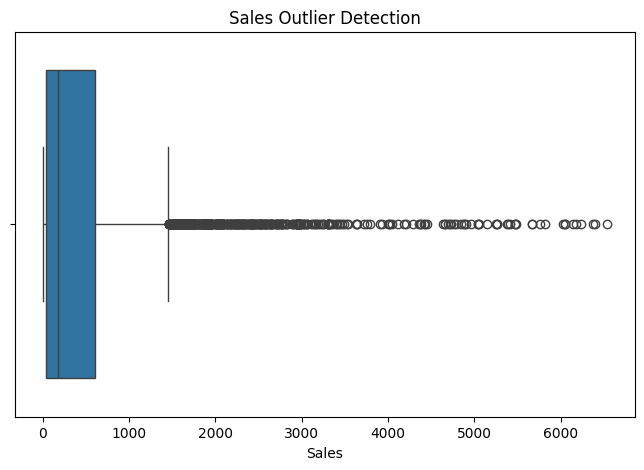

In [498]:
# Outlier Detection - Sales

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Sales'])
plt.title('Sales Outlier Detection')
plt.xlabel('Sales')
plt.show()

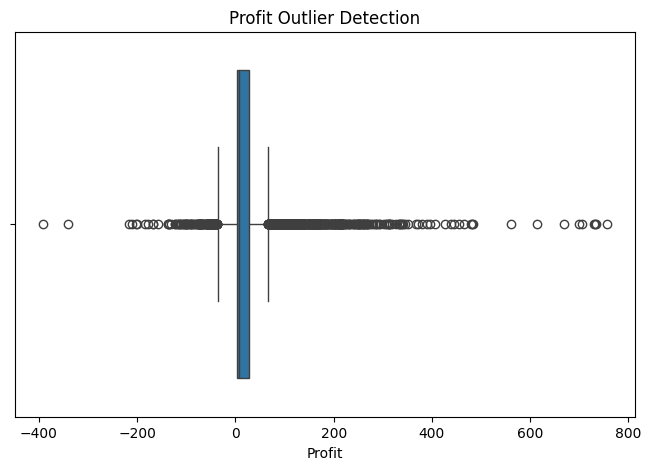

In [499]:
# Outlier Detection - Profit

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Profit'])
plt.title('Profit Outlier Detection')
plt.xlabel('Profit')
plt.show()

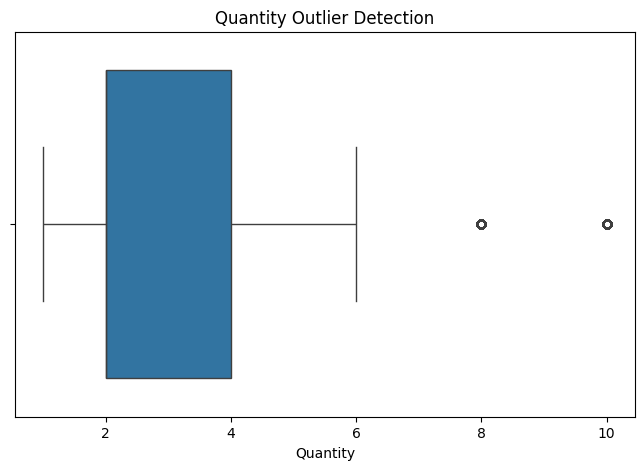

In [500]:
# Outlier Detection - Quantity

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Quantity'])
plt.title('Quantity Outlier Detection')
plt.xlabel('Quantity')
plt.show()

In [501]:
# IQR method for outlier detection

def count_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    return len(outliers), lower_limit, upper_limit


for column in ['Sales', 'Profit', 'Quantity']:
    if column in df.columns:
        count, lower, upper = count_outliers(column)

        print(f"\n{column}")
        print("Lower limit:", lower)
        print("Upper limit:", upper)
        print("Number of outliers:", count)


Sales
Lower limit: -821.3837500000001
Upper limit: 1456.34625
Number of outliers: 455

Profit
Lower limit: -36.28125000000001
Upper limit: 66.86875
Number of outliers: 686

Quantity
Lower limit: -1.0
Upper limit: 7.0
Number of outliers: 333


In [502]:
# Fill missing numerical values with median

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

for column in numeric_cols:
    df[column] = df[column].fillna(df[column].median())

print("Missing numerical values handled.")

Missing numerical values handled.


In [503]:
# Fill missing categorical values with mode

categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns

for column in categorical_cols:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing categorical values handled.")

Missing categorical values handled.


In [504]:
# Verify missing values after treatment

total_missing = df.isnull().sum().sum()

print("Total missing values after preprocessing:", total_missing)

Total missing values after preprocessing: 0


In [505]:
# Convert numerical columns to numeric data type

numeric_columns = [
    'Quantity',
    'Unit_Price',
    'Discount',
    'Sales',
    'Profit',
    'Year',
    'Month_Number',
    'Profit_Margin'
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors='coerce'
        )

print("Numerical columns converted successfully!")

Numerical columns converted successfully!


In [506]:
# Check data types after conversion

print(df.dtypes)

Order_ID                    object
Order_Date          datetime64[ns]
Customer_Name               object
Customer_Segment            object
Product_Name                object
Category                    object
Sub_Category                object
Region                      object
City                        object
Quantity                     int64
Unit_Price                 float64
Discount                   float64
Sales                      float64
Profit                     float64
Payment_Method              object
Year                         int64
Month                       object
Month_Number                 int64
Quarter                     object
Profit_Margin              float64
Unnamed: 20                float64
Unnamed: 21                float64
Profit_Status               object
Order_Year                   int32
Order_Month                  int32
Order_Day                    int32
Order_Weekday                int32
dtype: object


In [507]:
# Check missing values

missing_values = df.isnull().sum()

display(
    missing_values[missing_values > 0]
)

,0


In [508]:
# Convert Order_Date to datetime

df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

print("Order_Date converted successfully!")
print("Data type:", df['Order_Date'].dtype)

Order_Date converted successfully!
Data type: datetime64[ns]


In [509]:
excel_file = pd.ExcelFile(file_name)

print("Available sheets:")
print(excel_file.sheet_names)

Available sheets:
['Sheet1', 'Sales_Data', 'Project_Summary']


In [510]:
# Load the actual Sales_Data sheet

df = pd.read_excel(
    file_name,
    sheet_name='Sales_Data'
)

print("Sales dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Sales dataset loaded successfully!
Rows: 5000
Columns: 22


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02


In [511]:
# Convert Order_Date to datetime

if 'Order_Date' in df.columns:
    df['Order_Date'] = pd.to_datetime(
        df['Order_Date'],
        errors='coerce'
    )
    print("Order_Date converted successfully!")
    print(df['Order_Date'].dtype)
else:
    print("Column 'Order_Date' not found in DataFrame. No conversion performed.")

Order_Date converted successfully!
datetime64[ns]


In [512]:
# Display the exact column names in your dataset

for i, column in enumerate(df.columns):
    print(i, repr(column))

0 'Order_ID'
1 'Order_Date'
2 'Customer_Name'
3 'Customer_Segment'
4 'Product_Name'
5 'Category'
6 'Sub_Category'
7 'Region'
8 'City'
9 'Quantity'
10 'Unit_Price'
11 'Discount'
12 'Sales'
13 'Profit'
14 'Payment_Method'
15 'Year'
16 'Month'
17 'Month_Number'
18 'Quarter'
19 'Profit_Margin'
20 'Unnamed: 20'
21 'Unnamed: 21'


In [513]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']


In [514]:
print(file_name)

Sales_Analysis_Dataset (14).xlsx


In [515]:
# Find columns containing "date"

date_columns = [
    col for col in df.columns
    if 'date' in str(col).lower()
]

print("Date-related columns found:", date_columns)

Date-related columns found: ['Order_Date']


In [516]:
# Check data types

print(df.dtypes)

Order_ID                    object
Order_Date          datetime64[ns]
Customer_Name               object
Customer_Segment            object
Product_Name                object
Category                    object
Sub_Category                object
Region                      object
City                        object
Quantity                     int64
Unit_Price                 float64
Discount                   float64
Sales                      float64
Profit                     float64
Payment_Method              object
Year                         int64
Month                       object
Month_Number                 int64
Quarter                     object
Profit_Margin              float64
Unnamed: 20                float64
Unnamed: 21                float64
dtype: object


In [517]:
# Verify that duplicates have been removed

print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [518]:
# Check data types

print("Data types of each column:")
print(df.dtypes)

Data types of each column:
Order_ID                    object
Order_Date          datetime64[ns]
Customer_Name               object
Customer_Segment            object
Product_Name                object
Category                    object
Sub_Category                object
Region                      object
City                        object
Quantity                     int64
Unit_Price                 float64
Discount                   float64
Sales                      float64
Profit                     float64
Payment_Method              object
Year                         int64
Month                       object
Month_Number                 int64
Quarter                     object
Profit_Margin              float64
Unnamed: 20                float64
Unnamed: 21                float64
dtype: object


In [519]:
# Check missing values

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_values.values,
    'Missing Percentage': (missing_values.values / len(df)) * 100
})

display(missing_table)

,Column,Missing Values,Missing Percentage
0,Order_ID,0,0.00
1,Order_Date,0,0.00
2,Customer_Name,0,0.00
3,Customer_Segment,0,0.00
4,Product_Name,0,0.00
5,Category,0,0.00
6,Sub_Category,0,0.00
7,Region,0,0.00
8,City,0,0.00
9,Quantity,0,0.00


In [520]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [521]:
if duplicate_count > 0:
    display(df[df.duplicated()])
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [522]:
print("===== DATA QUALITY SUMMARY =====")
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

===== DATA QUALITY SUMMARY =====
Total rows: 5000
Total columns: 22
Missing values: 9993
Duplicate rows: 0


In [523]:
# Check for missing values

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_values.values,
    'Missing Percentage': (missing_values.values / len(df)) * 100
})

display(missing_table)

,Column,Missing Values,Missing Percentage
0,Order_ID,0,0.00
1,Order_Date,0,0.00
2,Customer_Name,0,0.00
3,Customer_Segment,0,0.00
4,Product_Name,0,0.00
5,Category,0,0.00
6,Sub_Category,0,0.00
7,Region,0,0.00
8,City,0,0.00
9,Quantity,0,0.00


In [524]:
# Basic Dataset Exploration

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())

print("\nStatistical Summary:")
display(df.describe(include='all').T)

Dataset Shape: (5000, 22)

Column Names:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          5000 non-null   object        
 1   Order_Date        5000 non-null   datetime64[ns]
 2   Customer_Name     5000 non-null   object        
 3   Customer_Segment  5000 non-null   object        
 4   Product_Name      5000 non-null   object        
 5   Category          5000 non-null   object        
 6   Sub_Category      5000 non-null   object        
 7   Region            5000 non-null   object       

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02



Statistical Summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,5000,5000,ORD04890,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,5000,NaN,NaN,NaN,2024-07-06 18:40:36.480000,2023-01-01 00:00:00,2023-10-13 00:00:00,2024-07-04 00:00:00,2025-04-09 00:00:00,2025-12-31 00:00:00,NaN
Customer_Name,5000,20,Riya Kulkarni,284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Segment,5000,3,Consumer,2863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Name,5000,20,Notebook Pack,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,5000,3,Technology,2220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub_Category,5000,11,Stationery,814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,5000,4,South,1468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5000,20,Coimbatore,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,5000.0,NaN,NaN,NaN,3.0752,1.0,2.0,2.0,4.0,10.0,2.116989
